# Forest Fire Containment — DQN vs Enhanced PN-DQN vs Rainbow DQN (20x20 Rich Grid)

| Feature | Detail |
|---|---|
| **20x20 grid** | Mountains, slopes, water bodies, humidity, temperature, living area |
| **10-channel obs** | fire, fuel, moisture, slope, elevation, living_mask, humidity, temp, dist_living, water |
| **MDP fire spread** | Vectorised Markov transition probabilities (8-direction, fully numpy) |
| **DQN** | Dueling Double DQN + PER (baseline) |
| **Enhanced PN-DQN** | Multi-scale CNN + Dense Blocks + Spatial Attention + Living-priority E-net |
| **Rainbow DQN** | C51 + N-step(3) + NoisyNets + Dueling + Double + PER *(recommended best)* |
| **GPU training** | 5 000 eps · batch 256 · buffer 200 k · `cudnn.benchmark=True` |
| **20x20 inference** | ARU living-area pattern; Rainbow agent trained directly on 20x20 |

In [1]:
import numpy as np, random, math, os
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import matplotlib.patches as mpatches
from matplotlib import animation
from IPython.display import HTML

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'Memory  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
Memory  : 8.6 GB
PyTorch : 2.5.1+cu121


## 1. Rich 20x20 Training Grid

**Terrain layers (8 fuel/terrain codes):**
`0`=Road · `1`=Grass · `2`=Tree · `3`=Shrub · `4`=Living area · `5`=Elec · `6`=Water · `7`=Rock (mountain)

**Key design decisions:**
- Mountains at **top-left** and **bottom-right** corners — high elevation drives uphill fire spread
- Diagonal **water stream** + small **lake** act as partial natural firebreaks
- **Roads** at row 9 and col 10 create a cross-shaped hard firebreak
- **Living area** (rows 2–8, cols 12–18) sits centre-right — threatened by all 3 ignitions
- **Ignitions**: (0,7) top-centre, (19,3) bottom-left, (0,19) top-right

**10-channel observation:** fire_state, fuel, moisture, slope, elevation,
living_mask, humidity, temperature, dist_to_living, water_mask

In [2]:
G = 20  # training grid

ROAD, GRASS, TREE, SHRUB, LIVING, ELEC, WATER, ROCK = 0, 1, 2, 3, 4, 5, 6, 7
N_FUEL = 8
FUEL_NAME = ['Road','Grass','Tree','Shrub','Living','Elec','Water','Rock']
FUEL_HEX  = ['#C2B280','#90EE90','#228B22','#8B6914','#B22222','#FFD700','#4169E1','#A0A0A0']
FIRE_HEX, BURNED_HEX = '#FF4500', '#1A0A00'


def build_terrain(Gv, seed=SEED):
    '''Return (fuel, elevation, slope, moisture, humidity, temperature) for GvxGv grid.'''
    rng = np.random.RandomState(seed)
    fuel = np.full((Gv, Gv), TREE, dtype=np.int32)

    # --- Mountains (rocky corners) ---
    for r in range(5):
        for c in range(5):
            if r + c < 6:          fuel[r, c]         = ROCK  # top-left
    for r in range(Gv-5, Gv):
        for c in range(Gv-5, Gv):
            if (Gv-1-r)+(Gv-1-c) < 6: fuel[r, c]     = ROCK  # bottom-right

    # --- Water bodies ---
    stream = [(r, 5) for r in range(3, 12)] + [(6, c) for c in range(5, 10)]
    lake   = [(r, c) for r in range(13, 17) for c in range(2, 7)
              if not (r == 15 and c in (4, 5))]
    for r, c in stream + lake:
        if 0 <= r < Gv and 0 <= c < Gv: fuel[r, c] = WATER

    # --- Roads (firebreaks) ---
    fuel[9, :]  = ROAD
    fuel[:, 10] = ROAD

    # --- Shrub transition zones ---
    for r in range(0, 9):
        for c in range(5, 10):
            if fuel[r, c] == TREE: fuel[r, c] = SHRUB
    for r in range(11, 17):
        for c in range(11, 16):
            if fuel[r, c] == TREE: fuel[r, c] = SHRUB

    # --- Grass patches ---
    for r in range(5, 9):
        for c in range(11, 15):
            if fuel[r, c] == TREE: fuel[r, c] = GRASS
    for r in range(11, 15):
        for c in range(6, 10):
            if fuel[r, c] == TREE: fuel[r, c] = GRASS

    # --- Living area (centre-right) ---
    for r in range(2, 9):
        for c in range(12, 19):
            if fuel[r, c] not in (ROAD, WATER, ROCK): fuel[r, c] = LIVING

    # --- Power lines ---
    for c in range(0, Gv, 5):
        for br in (1, Gv-2):
            if fuel[br, c] not in (ROAD, WATER, ROCK, LIVING): fuel[br, c] = ELEC

    # --- Elevation: mountains high, valley low ---
    elevation = np.zeros((Gv, Gv), dtype=np.float32)
    for r in range(Gv):
        for c in range(Gv):
            d_tl = np.sqrt(r**2 + c**2)
            d_br = np.sqrt((r-Gv+1)**2 + (c-Gv+1)**2)
            elevation[r, c] = max(0.0, 100.0 - d_tl*10, 100.0 - d_br*10)
    elevation = elevation.clip(0, 100)

    # --- Slope (gradient magnitude) ---
    gy, gx = np.gradient(elevation)
    slope = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2) / 30)).astype(np.float32).clip(0, 89)

    # --- Moisture: high near water ---
    moisture = np.full((Gv, Gv), 0.3, dtype=np.float32)
    wc_list = [(r, c) for r in range(Gv) for c in range(Gv) if fuel[r, c] == WATER]
    for wr, wcc in wc_list:
        for r in range(Gv):
            for c in range(Gv):
                d = np.sqrt((r-wr)**2 + (c-wcc)**2)
                moisture[r, c] = min(1.0, moisture[r, c] + 0.5*np.exp(-d*0.4))
    moisture[fuel == WATER] = 1.0
    moisture[fuel == ROCK]  = 0.05
    moisture = moisture.clip(0, 1)

    # --- Humidity (air moisture, slightly randomised) ---
    humidity = (moisture * 0.7 + rng.uniform(0.1, 0.3, (Gv, Gv)).astype(np.float32)).clip(0, 1)

    # --- Temperature (inverse of moisture; hotter on dry slopes) ---
    temperature = (0.5 + elevation/200.0 - moisture*0.3).clip(0.1, 0.95).astype(np.float32)

    return fuel, elevation, slope, moisture, humidity, temperature


(FIXED_FUEL, FIXED_ELEVATION, FIXED_SLOPE,
 FIXED_MOISTURE, FIXED_HUMIDITY, FIXED_TEMPERATURE) = build_terrain(G)

FIXED_LIVING_MASK = (FIXED_FUEL == LIVING).astype(np.float32)
FIXED_WATER_MASK  = (FIXED_FUEL == WATER ).astype(np.float32)

# Distance-to-living area (normalised 0-1)
_lr, _lc = np.where(FIXED_FUEL == LIVING)
def _dist_living_grid(fuel_arr, Gv):
    lr, lc = np.where(fuel_arr == LIVING)
    out = np.zeros((Gv, Gv), dtype=np.float32)
    for r in range(Gv):
        for c in range(Gv):
            if len(lr) == 0: out[r, c] = 1.0
            else: out[r, c] = float(np.min(np.sqrt((lr-r)**2+(lc-c)**2)))/(Gv*np.sqrt(2))
    return out

FIXED_DIST_LIVING = _dist_living_grid(FIXED_FUEL, G)
FIXED_IGNITIONS   = [(0, 7), (19, 3), (0, 19)]

OBS_CH    = 10
OBS_SHAPE = (OBS_CH, G, G)
N_ACT     = G * G

print(f"Grid         : {G}x{G}")
print(f"Obs shape    : {OBS_SHAPE}")
print(f"Action space : {N_ACT}")
fuel_counts = {FUEL_NAME[k]: int(v) for k, v in zip(*np.unique(FIXED_FUEL, return_counts=True))}
print(f"Fuel counts  : {fuel_counts}")

Grid         : 20x20
Obs shape    : (10, 20, 20)
Action space : 400
Fuel counts  : {'Road': 39, 'Grass': 18, 'Tree': 158, 'Shrub': 64, 'Living': 49, 'Elec': 4, 'Water': 30, 'Rock': 38}


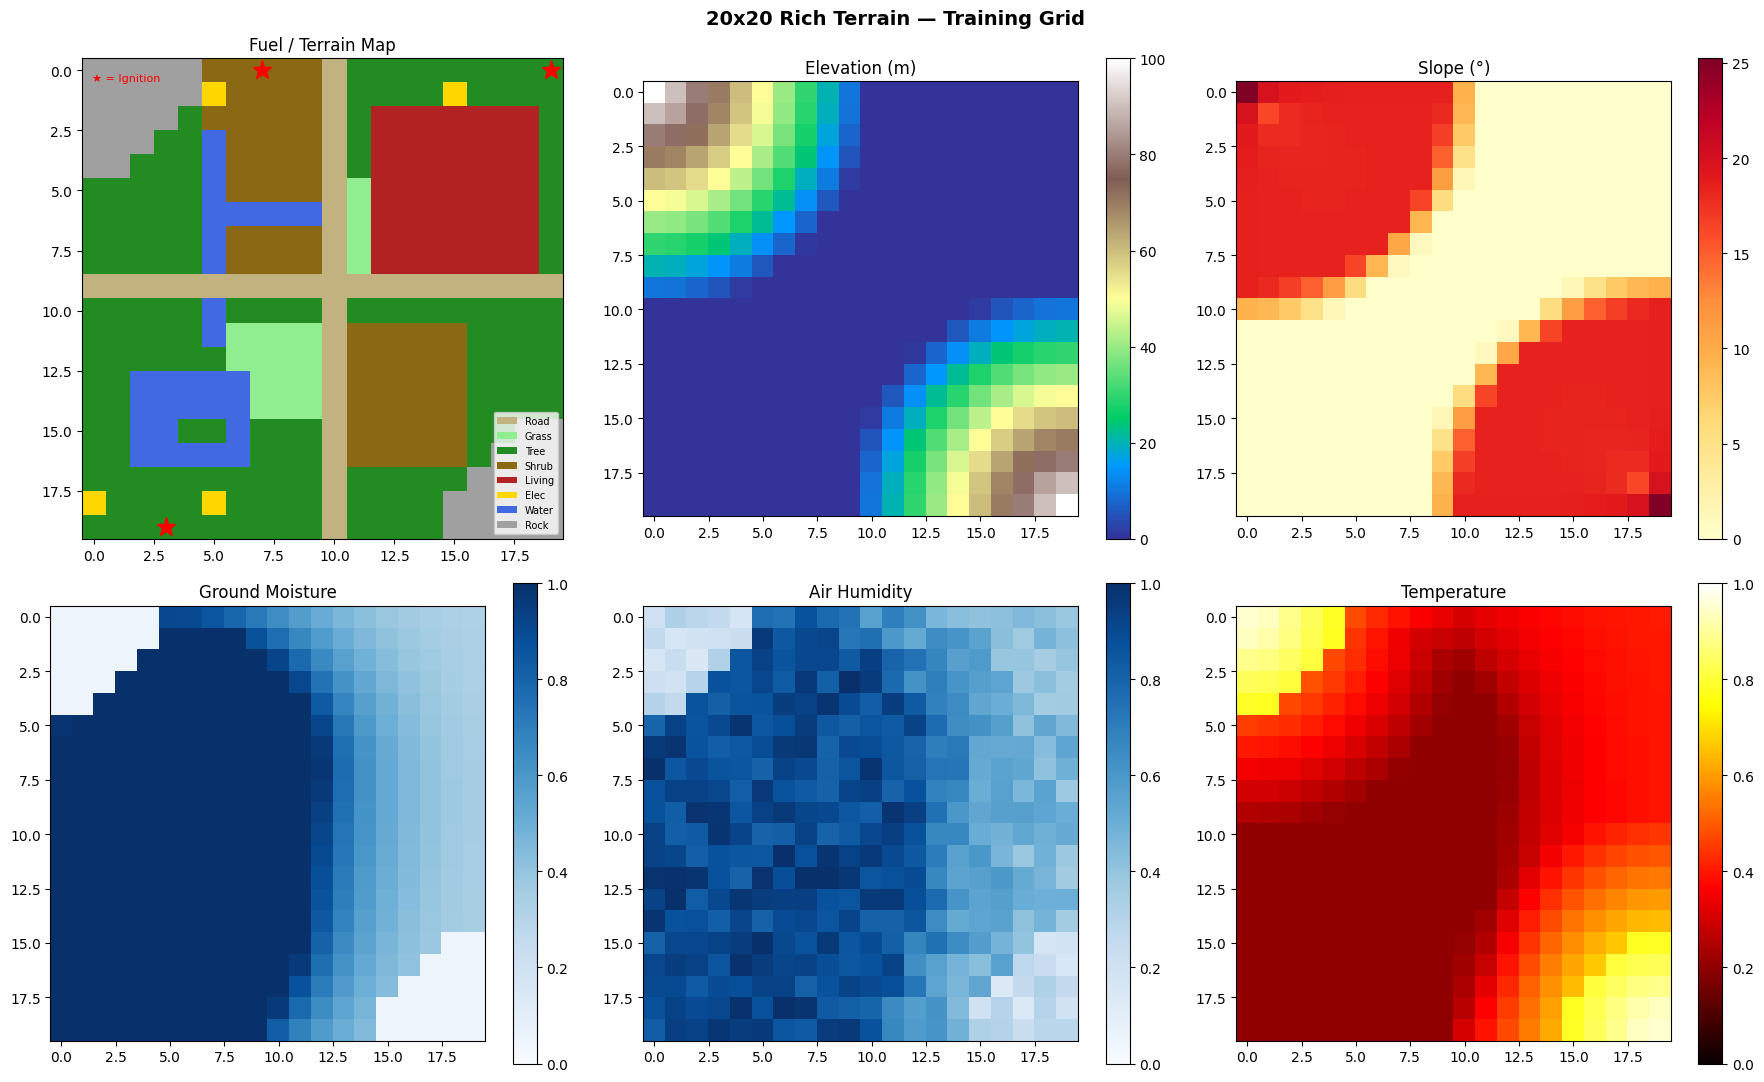

Saved → terrain_overview.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

fuel_cmap = mc.ListedColormap(FUEL_HEX)
fuel_norm = mc.BoundaryNorm(range(N_FUEL+1), N_FUEL)
axes[0,0].imshow(FIXED_FUEL, cmap=fuel_cmap, norm=fuel_norm, origin='upper')
axes[0,0].set_title('Fuel / Terrain Map', fontsize=12)
patches = [mpatches.Patch(facecolor=FUEL_HEX[i], label=FUEL_NAME[i]) for i in range(N_FUEL)]
axes[0,0].legend(handles=patches, loc='lower right', fontsize=7)
for r, c in FIXED_IGNITIONS:
    axes[0,0].plot(c, r, 'r*', ms=14, zorder=5)
axes[0,0].text(0.02, 0.97, '★ = Ignition', transform=axes[0,0].transAxes,
               fontsize=8, color='red', va='top')

im1 = axes[0,1].imshow(FIXED_ELEVATION, cmap='terrain', origin='upper')
axes[0,1].set_title('Elevation (m)', fontsize=12)
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[0,2].imshow(FIXED_SLOPE, cmap='YlOrRd', origin='upper')
axes[0,2].set_title('Slope (°)', fontsize=12)
plt.colorbar(im2, ax=axes[0,2])

im3 = axes[1,0].imshow(FIXED_MOISTURE, cmap='Blues', vmin=0, vmax=1, origin='upper')
axes[1,0].set_title('Ground Moisture', fontsize=12)
plt.colorbar(im3, ax=axes[1,0])

im4 = axes[1,1].imshow(FIXED_HUMIDITY, cmap='Blues', vmin=0, vmax=1, origin='upper')
axes[1,1].set_title('Air Humidity', fontsize=12)
plt.colorbar(im4, ax=axes[1,1])

im5 = axes[1,2].imshow(FIXED_TEMPERATURE, cmap='hot', vmin=0, vmax=1, origin='upper')
axes[1,2].set_title('Temperature', fontsize=12)
plt.colorbar(im5, ax=axes[1,2])

plt.suptitle('20x20 Rich Terrain — Training Grid', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('terrain_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved → terrain_overview.png")

In [5]:
PARAMS = {
    # ── Environment ──────────────────────────────────────────────────────────
    'grid_size'               : G,
    'cell_size_m'             : 30,
    'max_steps'               : 150,
    'n_cuts_per_step'         : 5,
    'warmup_steps'            : 3,

    # ── Physics ───────────────────────────────────────────────────────────────
    'wind_speed'              : 0.60,
    'wind_direction'          : 45.0,
    'wind_effect'             : 0.60,
    'moisture_effect'         : 0.80,
    'humidity_effect'         : 0.40,
    'slope_effect'            : 0.50,
    'temperature_effect'      : 0.30,

    # ── Rewards (shared) ─────────────────────────────────────────────────────
    'rw_cut_base'             : 0.05,
    'rw_cut_adj_bonus'        : 0.50,
    'rw_living_adj_bonus'     : 1.20,
    'rw_burn_penalty'         : 0.30,
    'rw_living_burn_penalty'  : 2.50,
    'rw_terminal_scale'       : 3.0,
    'rw_living_terminal_scale': 10.0,
    'rw_proximity_bonus'      : 0.15,

    # ── Training (GPU) ────────────────────────────────────────────────────────
    'n_episodes'              : 5000,
    'log_every'               : 500,
    'n_eval'                  : 60,
    'anim_seed'               : 7,

    # ── DQN ──────────────────────────────────────────────────────────────────
    'dqn_lr'                  : 2e-4,
    'dqn_gamma'               : 0.99,
    'dqn_eps_start'           : 1.0,
    'dqn_eps_min'             : 0.02,
    'dqn_eps_decay'           : 0.9994,
    'dqn_bs'                  : 256,
    'dqn_target_upd'          : 10,
    'dqn_hidden'              : 512,
    'dqn_buf_cap'             : 200_000,
    'dqn_per_alpha'           : 0.6,
    'dqn_per_beta'            : 0.4,
    'dqn_per_frames'          : 200_000,

    # ── Enhanced PN-DQN ───────────────────────────────────────────────────────
    'pndqn_lr'                : 2e-4,
    'pndqn_gamma'             : 0.99,
    'pndqn_eps_start'         : 1.0,
    'pndqn_eps_min'           : 0.02,
    'pndqn_eps_decay'         : 0.9994,
    'pndqn_bs'                : 256,
    'pndqn_target_upd'        : 10,
    'pndqn_hidden'            : 512,
    'pndqn_buf_cap'           : 200_000,
    'pndqn_per_alpha'         : 0.6,
    'pndqn_per_beta'          : 0.4,
    'pndqn_per_frames'        : 200_000,
    'pndqn_pretrain_eps'      : 400,
    'pndqn_growth_rate'       : 32,
    'pndqn_dense_layers'      : 3,

    # ── Rainbow DQN (best model) ──────────────────────────────────────────────
    'rainbow_lr'              : 1e-4,
    'rainbow_gamma'           : 0.99,
    'rainbow_bs'              : 256,
    'rainbow_target_upd'      : 10,
    'rainbow_hidden'          : 512,
    'rainbow_buf_cap'         : 200_000,
    'rainbow_per_alpha'       : 0.5,
    'rainbow_per_beta'        : 0.4,
    'rainbow_per_frames'      : 200_000,
    'rainbow_n_atoms'         : 51,
    'rainbow_v_min'           : -40.0,
    'rainbow_v_max'           : 40.0,
    'rainbow_n_step'          : 3,

    # ── PPO ───────────────────────────────────────────────────────────────────
    'ppo_lr'                  : 2e-4,
    'ppo_gamma'               : 0.99,
    'ppo_lam'                 : 0.95,
    'ppo_clip'                : 0.20,
    'ppo_epochs'              : 6,
    'ppo_vf_coef'             : 0.50,
    'ppo_ent_coef'            : 0.01,
    'ppo_hidden'              : 512,
    'ppo_max_grad'            : 0.5,
}

print("PARAMS set (GPU-optimised, 4 models):")
print(f"  Episodes        : {PARAMS['n_episodes']}")
print(f"  Batch size      : {PARAMS['dqn_bs']}")
print(f"  Replay buffer   : {PARAMS['dqn_buf_cap']:,}")
print(f"  Cuts per step   : {PARAMS['n_cuts_per_step']}")
print(f"  Max steps/ep    : {PARAMS['max_steps']}")
print(f"  Living penalty  : {PARAMS['rw_living_burn_penalty']} per cell ({PARAMS['rw_living_burn_penalty']/PARAMS['rw_burn_penalty']:.0f}x normal)")
print(f"  Living terminal : {PARAMS['rw_living_terminal_scale']}x scale")

PARAMS set (GPU-optimised, 4 models):
  Episodes        : 5000
  Batch size      : 256
  Replay buffer   : 200,000
  Cuts per step   : 5
  Max steps/ep    : 150
  Living penalty  : 2.5 per cell (8x normal)
  Living terminal : 10.0x scale


## 2. Rich Fire Environment — Vectorised MDP Spread

### Markov Decision Process Fire Propagation
At each timestep the fire spread follows:

$$P(\text{cell ignites}) = 1 - \prod_{d \in \text{8 dirs}} \left(1 - p_d \cdot \mathbb{1}[\text{source}_d\text{ burning}]\right)$$

where $p_d$ = `base_prob x wind_factor x slope_factor x temperature_factor x humidity_factor x (1 − moisture x effect)`

**Static pre-computation**: slope, wind, temperature, and humidity factors are computed once per direction before training.
**Dynamic application**: only the moisture channel (which changes when cells are cut) is applied per step.
This reduces the inner fire-spread loop from O(G²x8) individual factor multiplications to a single vectorised numpy pass.

In [6]:
class RichFireEnv:
    '''
    20x20 (or arbitrary Gv) rich wildfire environment.
    10-channel observation. Vectorised MDP fire spread.
    Living area carries 2.5x burn penalty + 10x terminal bonus.
    '''
    UNBURNED, BURNING, BURNED = 0, 1, 2
    ROAD,GRASS,TREE,SHRUB,LIVING,ELEC,WATER,ROCK = 0,1,2,3,4,5,6,7
    BASE_PROB     = np.array([0.00,0.75,0.65,0.80,0.55,0.50,0.00,0.00], np.float32)
    BURN_DURATION = np.array([0,   2,   4,   3,   3,   2,   0,   0  ], np.int32)
    DIRS = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

    def __init__(self, params, obs_ch,
                 fuel=None, elevation=None, slope=None,
                 moisture=None, humidity=None, temperature=None,
                 ignitions=None, living_mask=None,
                 water_mask=None, dist_living=None):
        self.p         = params
        self.G         = params['grid_size']
        self.obs_shape = (obs_ch, self.G, self.G)
        self.obs_ch    = obs_ch
        self.n_act     = self.G * self.G

        self._f0  = (fuel        if fuel        is not None else FIXED_FUEL       ).copy()
        self._e0  = (elevation   if elevation   is not None else FIXED_ELEVATION  ).copy()
        self._s0  = (slope       if slope       is not None else FIXED_SLOPE      ).copy()
        self._m0  = (moisture    if moisture    is not None else FIXED_MOISTURE   ).copy()
        self._h0  = (humidity    if humidity    is not None else FIXED_HUMIDITY   ).copy()
        self._t0  = (temperature if temperature is not None else FIXED_TEMPERATURE).copy()
        self._ig  = ignitions if ignitions is not None else FIXED_IGNITIONS
        self._lm  = (living_mask if living_mask is not None
                     else (self._f0==LIVING).astype(np.float32))
        self._wm  = (water_mask  if water_mask  is not None
                     else (self._f0==WATER).astype(np.float32))
        self._dl  = (dist_living if dist_living is not None else FIXED_DIST_LIVING)
        self._precompute_static()

    # ── MDP static component ─────────────────────────────────────────────────
    def _shift(self, arr, dr, dc):
        G = self.G; out = np.zeros((G,G), dtype=arr.dtype)
        r1,r2 = max(0,dr), G+min(0,dr)
        c1,c2 = max(0,dc), G+min(0,dc)
        rs,re = max(0,-dr), G-max(0,dr)
        cs,ce = max(0,-dc), G-max(0,dc)
        out[r1:r2,c1:c2] = arr[rs:re,cs:ce]
        return out

    def _precompute_static(self):
        p, f, e = self.p, self._f0, self._e0
        self._sp = {}
        for dr,dc in self.DIRS:
            prob = self.BASE_PROB[f].copy()
            prob *= (1.0 - self._h0 * p['humidity_effect'])
            prob *= (1.0 + (self._t0 - 0.5) * p['temperature_effect'])
            src_e = self._shift(e, dr, dc)
            dz    = (e - src_e).astype(np.float32)
            dist  = float(np.sqrt(dr**2+dc**2)) * p['cell_size_m']
            ang   = np.degrees(np.arctan(dz / max(dist, 1e-3)))
            prob *= np.clip(np.exp(ang * p['slope_effect'] / 45.0), 0.05, 3.0)
            az   = np.degrees(np.arctan2(float(dc), -float(dr))) % 360
            diff = abs(p['wind_direction'] - az) % 360
            if diff > 180: diff = 360 - diff
            wf   = 1.0 + p['wind_speed']*p['wind_effect']*np.cos(np.radians(diff))
            prob *= float(np.clip(wf, 0.0, 3.0))
            prob[f==self.WATER] = 0.0
            prob[f==self.ROCK ] = 0.0
            prob[f==self.ROAD ] = 0.0
            self._sp[(dr,dc)] = np.clip(prob, 0.0, 1.0).astype(np.float32)

    # ── Reset ────────────────────────────────────────────────────────────────
    def reset(self):
        G = self.G
        self.fuel       = self._f0.copy()
        self.elev       = self._e0.copy()
        self.fire_state = np.zeros((G,G), np.int32)
        self.burn_timer = np.zeros((G,G), np.int32)
        self.step_count = 0
        self._prev_burned = set()
        for r,c in self._ig:
            ft = self.fuel[r,c]
            if 0<=r<G and 0<=c<G and ft not in (self.WATER,self.ROCK,self.ROAD):
                self.fire_state[r,c] = self.BURNING
                self.burn_timer[r,c] = int(self.BURN_DURATION[ft])
        ok = (self.fuel>0)&(self.fuel!=self.WATER)&(self.fuel!=self.ROCK)
        self.initial_burnable = int(np.sum(ok))
        self.initial_living   = int(np.sum(self.fuel==self.LIVING))
        return self._obs()

    # ── Vectorised MDP spread ────────────────────────────────────────────────
    def _mdp_spread(self):
        G       = self.G
        burning = (self.fire_state==self.BURNING).astype(np.float32)
        no_ign  = np.ones((G,G), np.float32)
        mmod    = (1.0 - self._m0 * self.p['moisture_effect']).clip(0.1, 1.0)
        for dr,dc in self.DIRS:
            src   = self._shift(burning, dr, dc)
            p_dir = (self._sp[(dr,dc)] * mmod).clip(0.0, 1.0)
            no_ign *= np.where(src > 0, 1.0 - p_dir, 1.0)
        p_ign = 1.0 - no_ign
        ok = ((self.fire_state==self.UNBURNED) & (self.fuel>0) &
              (self.fuel!=self.WATER) & (self.fuel!=self.ROCK) & (self.fuel!=self.ROAD))
        ignite = ok & (np.random.random((G,G)) < p_ign)
        self.fire_state[ignite] = self.BURNING
        self.burn_timer[ignite] = self.BURN_DURATION[self.fuel[ignite]]
        on = (self.fire_state==self.BURNING)
        self.burn_timer[on] -= 1
        self.fire_state[on & (self.burn_timer<=0)] = self.BURNED

    # ── Step ─────────────────────────────────────────────────────────────────
    def step(self, actions):
        if isinstance(actions, (int, np.integer)): actions = [int(actions)]
        G, p = self.G, self.p
        reward = 0.0
        for action in actions:
            r,c = divmod(int(action), G)
            ft  = self.fuel[r,c]
            if ft in (self.GRASS, self.TREE, self.SHRUB):
                adj_f = any(0<=r+dr<G and 0<=c+dc<G and
                            self.fire_state[r+dr,c+dc]==self.BURNING
                            for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)])
                adj_l = any(0<=r+dr<G and 0<=c+dc<G and
                            self.fuel[r+dr,c+dc]==self.LIVING
                            for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)])
                self.fuel[r,c] = self.ROAD
                reward += p['rw_cut_base']
                if adj_f: reward += p['rw_cut_adj_bonus']
                if adj_l: reward += p['rw_living_adj_bonus']
                reward += p['rw_proximity_bonus'] * (1.0 - float(self._dl[r,c]))
        self._mdp_spread()
        self.step_count += 1
        for row in range(G):
            for col in range(G):
                if self.fire_state[row,col]==self.BURNED:
                    k = (row,col)
                    if k not in self._prev_burned:
                        self._prev_burned.add(k)
                        orig = self._f0[row,col]
                        if orig == self.LIVING:
                            reward -= p['rw_living_burn_penalty']
                        elif orig>0 and orig not in (self.WATER,self.ROCK):
                            reward -= p['rw_burn_penalty']
        fires  = int(np.sum(self.fire_state==self.BURNING))
        burned = int(np.sum(self.fire_state==self.BURNED))
        intact = int(np.sum((self.fire_state==self.UNBURNED)&(self.fuel>0)&
                             (self.fuel!=self.WATER)&(self.fuel!=self.ROCK)))
        living_intact = int(np.sum((self.fire_state==self.UNBURNED)&(self._f0==self.LIVING)))
        done = (fires==0) or (self.step_count>=p['max_steps'])
        if done:
            reward += (intact/max(self.initial_burnable,1)) * p['rw_terminal_scale']
            reward += (living_intact/max(self.initial_living,1)) * p['rw_living_terminal_scale']
        info = {'fires':fires,'intact':intact,'burned':burned,
                'living_intact':living_intact,'living_total':self.initial_living}
        return self._obs(), reward, done, info

    def _obs(self):
        emax = float(self.elev.max()) or 1.0
        return np.stack([
            self.fire_state/2.0, self.fuel/float(N_FUEL-1),
            self._m0, self._s0/90.0, self.elev/emax,
            self._lm, self._h0, self._t0, self._dl, self._wm
        ]).astype(np.float32)

    def render_rgb(self):
        G = self.G
        rgb = np.ones((G,G,3), np.float32)
        for ft, hx in enumerate(FUEL_HEX):
            rgb[self._f0==ft] = mc.to_rgb(hx)
        rgb[self.fuel==ROAD]               = mc.to_rgb('#C2B280')
        rgb *= np.clip(1.0-self._m0*0.3, 0.4, 1.0)[:,:,None]
        rgb[self.fire_state==self.BURNING] = mc.to_rgb(FIRE_HEX)
        rgb[self.fire_state==self.BURNED ] = mc.to_rgb(BURNED_HEX)
        return np.clip(rgb, 0, 1)


_e = RichFireEnv(PARAMS, OBS_CH); _o = _e.reset()
print(f"Env obs shape  : {_o.shape}  (10 channels)")
print(f"Burnable cells : {_e.initial_burnable}")
print(f"Living cells   : {_e.initial_living}  <- protect at all cost")
del _e, _o

Env obs shape  : (10, 20, 20)  (10 channels)
Burnable cells : 293
Living cells   : 49  <- protect at all cost


## 3. Shared Neural Components

- **NoisyLinear** (Fortunato et al. 2017): factorised Gaussian noise on weights — replaces ε-greedy in Rainbow
- **PER** (Schaul et al. 2015): proportional prioritised replay (used by all three agents)
- **NStepPER**: N-step return buffer wrapping PER (Rainbow only)
- **DenseLayer / DenseBlock**: DenseNet building blocks (PN-DQN backbone)

In [ ]:
# ── NoisyLinear ──────────────────────────────────────────────────────────────
class NoisyLinear(nn.Module):
    '''Factorised Gaussian NoisyNet layer (Fortunato et al. 2017).'''
    def __init__(self, in_f, out_f, std_init=0.5):
        super().__init__()
        self.in_f = in_f; self.out_f = out_f
        self.w_mu    = nn.Parameter(torch.empty(out_f, in_f))
        self.w_sigma = nn.Parameter(torch.empty(out_f, in_f))
        self.b_mu    = nn.Parameter(torch.empty(out_f))
        self.b_sigma = nn.Parameter(torch.empty(out_f))
        self.register_buffer('w_eps', torch.empty(out_f, in_f))
        self.register_buffer('b_eps', torch.empty(out_f))
        self.std_init = std_init
        self.reset_parameters(); self.sample_noise()

    def reset_parameters(self):
        mu_range = 1.0 / math.sqrt(self.in_f)
        self.w_mu.data.uniform_(-mu_range, mu_range)
        self.w_sigma.data.fill_(self.std_init / math.sqrt(self.in_f))
        self.b_mu.data.uniform_(-mu_range, mu_range)
        self.b_sigma.data.fill_(self.std_init / math.sqrt(self.out_f))

    @staticmethod
    def _f(x):
        return x.sign() * x.abs().sqrt()

    def sample_noise(self):
        ei = self._f(torch.randn(self.in_f,  device=self.w_eps.device))
        eo = self._f(torch.randn(self.out_f, device=self.w_eps.device))
        self.w_eps.copy_(eo.outer(ei))
        self.b_eps.copy_(eo)

    def forward(self, x):
        if self.training:
            w = self.w_mu + self.w_sigma * self.w_eps
            b = self.b_mu + self.b_sigma * self.b_eps
        else:
            w, b = self.w_mu, self.b_mu
        return F.linear(x, w, b)


# ── PER ───────────────────────────────────────────────────────────────────────
class PER:
    def __init__(self, cap, alpha=0.6, beta0=0.4, beta_frames=200_000):
        self.cap = cap; self.alpha = alpha; self.beta = beta0
        self.beta_inc = (1.0-beta0)/beta_frames
        self.buf = []; self.prio = np.zeros(cap, np.float32); self.pos = 0; self.max_p = 1.0

    def push(self, *t):
        if len(self.buf) < self.cap: self.buf.append(t)
        else: self.buf[self.pos] = t
        self.prio[self.pos] = self.max_p; self.pos = (self.pos+1) % self.cap

    def sample(self, n):
        sz = len(self.buf); pr = self.prio[:sz]**self.alpha; pr /= pr.sum()
        idx = np.random.choice(sz, n, replace=False, p=pr)
        w = (sz*pr[idx])**(-self.beta); w /= w.max()
        self.beta = min(1.0, self.beta+self.beta_inc)
        s,a,r,s2,d = zip(*[self.buf[i] for i in idx])
        return (np.array(s,np.float32), np.array(a,np.int64), np.array(r,np.float32),
                np.array(s2,np.float32), np.array(d,np.float32), idx, w.astype(np.float32))

    def update(self, idx, p):
        for i,v in zip(idx,p): self.prio[i]=float(v); self.max_p=max(self.max_p,float(v))

    def __len__(self): return len(self.buf)


#
 ── N-Step PER (Rainbow) ──────────────────────────────────────────────────────
class NStepPER:
    def __init__(self, cap, n_step, gamma, alpha=0.5, beta0=0.4, beta_frames=200_000):
        self.per = PER(cap, alpha, beta0, beta_frames)
        self.n = n_step; self.gamma = gamma
        self._buf = deque(maxlen=n_step)

    def _flush_one(self):
        if not self._buf: return
        s, a, _, _, _ = self._buf[0]
        _, _, _, s2, d = self._buf[-1]
        n_r = 0.0; done = False
        for i,(_, _, r, _, dn) in enumerate(self._buf):
            n_r += (self.gamma**i) * r
            if dn: done = True; break
        self.per.push(s, a, n_r, s2, float(done))
        self._buf.popleft()

    def push(self, s, a, r, s2, done):
        self._buf.append((s,a,r,s2,done))
        if len(self._buf) == self.n: self._flush_one()
        if done:
            while self._buf: self._flush_one()

    def sample(self, n): return self.per.sample(n)
    def update(self, idx, p): self.per.update(idx, p)
    def __len__(self): return len(self.per)


# ── Dense Blocks (PN-DQN backbone) ───────────────────────────────────────────
class DenseLayer(nn.Module):
    def __init__(self, in_ch, growth):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_ch)
        self.cv = nn.Conv2d(in_ch, growth, 3, padding=1, bias=False)
    def forward(self, x):
        return torch.cat([x, self.cv(F.relu(self.bn(x)))], dim=1)

class DenseBlock(nn.Module):
    def __init__(self, in_ch, growth, n):
        super().__init__()
        self.layers = nn.ModuleList()
        ch = in_ch
        for _ in range(n):
            self.layers.append(DenseLayer(ch, growth)); ch += growth
        self.out_ch = ch
    def forward(self, x):
        for l in self.layers: x = l(x)
        return x

class TransitionLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_ch)
        self.cv = nn.Conv2d(in_ch, out_ch, 1, bias=False)
    def forward(self, x): return self.cv(F.relu(self.bn(x)))

print("Shared components ready: NoisyLinear, PER, NStepPER, DenseBlock")

Shared components ready: NoisyLinear, PER, NStepPER, DenseBlock


## 4. Model 1 — DQN: Dueling Double DQN + PER (Baseline)

3-layer CNN → Dueling head (Value + Advantage streams) + Double Q-target + Prioritised Replay.

In [8]:
class DuelingCNN(nn.Module):
    def __init__(self, in_ch, Gv, n_act, h=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_ch,  64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64,    128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128,    64, 3, padding=1), nn.ReLU())
        flat = 64 * Gv * Gv
        self.val = nn.Sequential(nn.Linear(flat,h), nn.ReLU(), nn.Linear(h,1))
        self.adv = nn.Sequential(nn.Linear(flat,h), nn.ReLU(), nn.Linear(h,n_act))

    def forward(self, x):
        f = self.cnn(x).flatten(1)
        V = self.val(f); A = self.adv(f)
        return V + A - A.mean(1, keepdim=True)


class DQNAgent:
    def __init__(self, obs_shape, n_act, p, prefix='dqn'):
        in_ch,Gv,_ = obs_shape; h = p[f'{prefix}_hidden']
        self.n_act=n_act; self.k=p['n_cuts_per_step']
        self.gamma=p[f'{prefix}_gamma']; self.eps=p[f'{prefix}_eps_start']
        self.eps_min=p[f'{prefix}_eps_min']; self.eps_dec=p[f'{prefix}_eps_decay']
        self.bs=p[f'{prefix}_bs']; self.tup=p[f'{prefix}_target_upd']; self._stp=0
        self.policy = DuelingCNN(in_ch,Gv,n_act,h).to(device)
        self.target = DuelingCNN(in_ch,Gv,n_act,h).to(device)
        self.target.load_state_dict(self.policy.state_dict()); self.target.eval()
        self.opt = optim.Adam(self.policy.parameters(), lr=p[f'{prefix}_lr'])
        self.buf = PER(p[f'{prefix}_buf_cap'], p[f'{prefix}_per_alpha'],
                       p[f'{prefix}_per_beta'], p[f'{prefix}_per_frames'])
        self.loss_fn = nn.SmoothL1Loss(reduction='none')

    def act(self, state, greedy=False):
        if not greedy and random.random() < self.eps:
            return random.sample(range(self.n_act), self.k)
        with torch.no_grad():
            q = self.policy(torch.from_numpy(state[None]).to(device))[0].cpu().numpy()
        return list(np.argsort(q)[-self.k:][::-1])

    def learn(self):
        if len(self.buf) < self.bs: return None
        s,a,r,s2,d,idx,w = self.buf.sample(self.bs)
        s  = torch.from_numpy(s).to(device)
        a  = torch.from_numpy(a).unsqueeze(1).to(device)
        r  = torch.from_numpy(r).to(device)
        s2 = torch.from_numpy(s2).to(device)
        d  = torch.from_numpy(d).to(device)
        w  = torch.from_numpy(w).to(device)
        qc = self.policy(s).gather(1,a).squeeze(1)
        with torch.no_grad():
            ba = self.policy(s2).argmax(1, keepdim=True)
            qt = r + self.gamma * self.target(s2).gather(1,ba).squeeze(1) * (1-d)
        td   = self.loss_fn(qc, qt)
        loss = (w * td).mean()
        self.opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), 10.0); self.opt.step()
        self.buf.update(idx, td.detach().cpu().numpy()+1e-6)
        self.eps = max(self.eps_min, self.eps*self.eps_dec)
        self._stp += 1
        if self._stp % self.tup == 0: self.target.load_state_dict(self.policy.state_dict())
        return float(loss.item())


_t = DQNAgent(OBS_SHAPE, N_ACT, PARAMS)
print(f"DQN policy params : {sum(p.numel() for p in _t.policy.parameters()):,}")
del _t

DQN policy params : 26,574,609


## 5. Model 2 — Enhanced PN-DQN (Multi-Scale · Dense · Attention · Living-Priority E-Net)

Improvements over Lv et al. (2019):

| Component | Original | Enhanced |
|---|---|---|
| CNN backbone | Plain 3-layer CNN | **Multi-scale** 3x3 + 5x5 parallel branches merged by 1x1 conv |
| Dense blocks | growth=16, 2 layers | **growth=32, 3 layers** (deeper feature reuse) |
| Attention | None | **CBAM spatial attention** (avg + max pool → sigmoid gate) |
| E-network | Simple FC | **Attention CNN + living-proximity weighted targets** |
| Exploration | ε-greedy | ε-greedy with **adaptive decay** based on living survival rate |
| Action select | top-k QxE | top-k Qx(E+0.1) — biases toward high-value living-adjacent cells |

In [9]:
# ── Multi-scale CNN stem ─────────────────────────────────────────────────────
class MultiScaleStem(nn.Module):
    def __init__(self, in_ch, out_ch=64):
        super().__init__()
        mid = out_ch // 2
        self.b3 = nn.Sequential(nn.Conv2d(in_ch, mid, 3, padding=1), nn.BatchNorm2d(mid), nn.ReLU())
        self.b5 = nn.Sequential(nn.Conv2d(in_ch, mid, 5, padding=2), nn.BatchNorm2d(mid), nn.ReLU())
        self.merge = nn.Sequential(nn.Conv2d(out_ch, out_ch, 1), nn.ReLU())
    def forward(self, x):
        return self.merge(torch.cat([self.b3(x), self.b5(x)], dim=1))


# ── CBAM Spatial Attention ───────────────────────────────────────────────────
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3)
    def forward(self, x):
        avg = x.mean(1, keepdim=True); mx = x.max(1, keepdim=True)[0]
        gate = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * gate


# ── Enhanced Q-network ────────────────────────────────────────────────────────
class EnhancedDenseDueling(nn.Module):
    def __init__(self, in_ch, Gv, n_act, h=512, growth=32, n_dense=3):
        super().__init__()
        self.stem = MultiScaleStem(in_ch, 64)
        db1 = DenseBlock(64, growth, n_dense); self.db1 = db1
        self.tr1 = TransitionLayer(db1.out_ch, 64)
        db2 = DenseBlock(64, growth, n_dense); self.db2 = db2
        self.tr2 = TransitionLayer(db2.out_ch, 128)
        self.attn = SpatialAttention()
        flat = 128 * Gv * Gv
        self.val = nn.Sequential(nn.Linear(flat,h), nn.ReLU(), nn.Linear(h,1))
        self.adv = nn.Sequential(nn.Linear(flat,h), nn.ReLU(), nn.Linear(h,n_act))

    def forward(self, x):
        x = self.stem(x)
        x = self.tr1(self.db1(x))
        x = self.tr2(self.db2(x))
        x = self.attn(x)
        f = x.flatten(1)
        V = self.val(f); A = self.adv(f)
        return V + A - A.mean(1, keepdim=True)


# ── Enhanced E-network (living-priority) ─────────────────────────────────────
class EnhancedEvalNet(nn.Module):
    def __init__(self, in_ch, Gv, n_act, h=256):
        super().__init__()
        self.cnn  = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32,    64, 3, padding=1), nn.ReLU())
        self.attn = SpatialAttention()
        self.fc   = nn.Sequential(nn.Linear(64*Gv*Gv, h), nn.ReLU(), nn.Linear(h, n_act))
    def forward(self, x):
        return self.fc(self.attn(self.cnn(x)).flatten(1))


# ── Enhanced PN-DQN Agent ─────────────────────────────────────────────────────
class EnhancedPNDQNAgent:
    '''
    Phase 1 (pretrain_eps): train E with random actions, targets weighted by
    proximity to living area so E naturally learns living-adjacent cells are valuable.
    Phase 2 (n_episodes):   train Q; select actions by top-k Q*(E+0.1).
    '''
    def __init__(self, obs_shape, n_act, p):
        in_ch,Gv,_ = obs_shape; h=p['pndqn_hidden']
        gr=p['pndqn_growth_rate']; dl=p['pndqn_dense_layers']
        self.n_act=n_act; self.k=p['n_cuts_per_step']
        self.gamma=p['pndqn_gamma']; self.eps=p['pndqn_eps_start']
        self.eps_min=p['pndqn_eps_min']; self.eps_dec=p['pndqn_eps_decay']
        self.bs=p['pndqn_bs']; self.tup=p['pndqn_target_upd']; self._stp=0
        self.pretrain_eps=p['pndqn_pretrain_eps']; self.e_trained=False

        self.policy = EnhancedDenseDueling(in_ch,Gv,n_act,h,gr,dl).to(device)
        self.target = EnhancedDenseDueling(in_ch,Gv,n_act,h,gr,dl).to(device)
        self.target.load_state_dict(self.policy.state_dict()); self.target.eval()
        self.eval_net = EnhancedEvalNet(in_ch,Gv,n_act).to(device)

        self.opt_q = optim.Adam(self.policy.parameters(),   lr=p['pndqn_lr'])
        self.opt_e = optim.Adam(self.eval_net.parameters(), lr=p['pndqn_lr'])
        self.buf   = PER(p['pndqn_buf_cap'], p['pndqn_per_alpha'],
                        p['pndqn_per_beta'], p['pndqn_per_frames'])
        self.loss_fn = nn.SmoothL1Loss(reduction='none')

        # Living-area proximity weights per action (precomputed)
        Gv2 = Gv
        dl_flat = FIXED_DIST_LIVING[:Gv2,:Gv2].flatten()
        self._liv_w = torch.from_numpy(1.0 - dl_flat.clip(0,1)).float().to(device)

    def act(self, state, greedy=False, use_eval=True):
        if not greedy and random.random() < self.eps:
            return random.sample(range(self.n_act), self.k)
        with torch.no_grad():
            t = torch.from_numpy(state[None]).to(device)
            q = self.policy(t)[0].cpu().numpy()
            if use_eval and self.e_trained:
                e = torch.sigmoid(self.eval_net(t)[0]).cpu().numpy()
                score = q * (e + 0.1)
            else:
                score = q
        return list(np.argsort(score)[-self.k:][::-1])

    def pretrain_e_step(self, state, actions, reward):
        t        = torch.from_numpy(state[None]).to(device)
        e_out    = self.eval_net(t)[0]
        target_e = torch.ones(self.n_act, device=device)
        r_per    = float(reward) / max(len(actions), 1)
        for a in actions:
            # Weight target by living proximity — cells near living area get higher targets
            liv_bonus = float(self._liv_w[a].item())
            target_e[a] = 1.0 + r_per * (1.0 + liv_bonus)
        loss = F.mse_loss(e_out, target_e)
        self.opt_e.zero_grad(); loss.backward(); self.opt_e.step()
        return float(loss.item())

    def learn(self):
        if len(self.buf) < self.bs: return None
        s,a,r,s2,d,idx,w = self.buf.sample(self.bs)
        s  = torch.from_numpy(s).to(device)
        a  = torch.from_numpy(a).unsqueeze(1).to(device)
        r  = torch.from_numpy(r).to(device)
        s2 = torch.from_numpy(s2).to(device)
        d  = torch.from_numpy(d).to(device)
        w  = torch.from_numpy(w).to(device)
        qc = self.policy(s).gather(1,a).squeeze(1)
        with torch.no_grad():
            ba = self.policy(s2).argmax(1, keepdim=True)
            qt = r + self.gamma * self.target(s2).gather(1,ba).squeeze(1)*(1-d)
        td   = self.loss_fn(qc, qt)
        loss = (w * td).mean()
        self.opt_q.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), 10.0); self.opt_q.step()
        self.buf.update(idx, td.detach().cpu().numpy()+1e-6)
        self.eps = max(self.eps_min, self.eps*self.eps_dec)
        self._stp += 1
        if self._stp % self.tup == 0: self.target.load_state_dict(self.policy.state_dict())
        return float(loss.item())


_t = EnhancedPNDQNAgent(OBS_SHAPE, N_ACT, PARAMS)
nq = sum(p.numel() for p in _t.policy.parameters())
ne = sum(p.numel() for p in _t.eval_net.parameters())
print(f"Enhanced PN-DQN Q-net params : {nq:,}")
print(f"Enhanced PN-DQN E-net params : {ne:,}")
del _t

Enhanced PN-DQN Q-net params : 52,849,268
Enhanced PN-DQN E-net params : 6,678,163


## 6. Model 3 — Rainbow DQN *(Recommended Best for Living-Area Protection)*

**Why Rainbow is best for this scenario:**
- **C51 distributional head** learns the *distribution* of future rewards, not just the mean — critical when living-area burn events produce high-variance penalties
- **N-step(3) returns** reduce temporal credit-assignment delay: agent learns to start firebreaks 3 steps before fire arrives
- **NoisyNets** provide state-dependent exploration, focusing noise near the fire-front rather than uniformly random
- **Dueling** separates "how dangerous is this state?" (Value) from "how good is this specific cut?" (Advantage)
- **Double DQN** prevents overestimation of building-adjacent Q-values
- **PER** over-samples the rare but important living-area burn events

In [10]:
class DistribDuelingNet(nn.Module):
    '''C51 Distributional Dueling Net with NoisyLinear heads.'''
    def __init__(self, in_ch, Gv, n_act, n_atoms=51, v_min=-40., v_max=40., h=512):
        super().__init__()
        self.n_act=n_act; self.n_atoms=n_atoms
        self.register_buffer('support', torch.linspace(v_min, v_max, n_atoms))
        self.cnn = nn.Sequential(
            nn.Conv2d(in_ch,  64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64,    128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128,   128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128,    64, 1),             nn.ReLU())
        flat = 64 * Gv * Gv
        self.val_h = NoisyLinear(flat, h); self.val_o = NoisyLinear(h, n_atoms)
        self.adv_h = NoisyLinear(flat, h); self.adv_o = NoisyLinear(h, n_act*n_atoms)

    def forward(self, x):
        f  = self.cnn(x).flatten(1)
        V  = self.val_o(F.relu(self.val_h(f))).view(-1,1,self.n_atoms)
        A  = self.adv_o(F.relu(self.adv_h(f))).view(-1,self.n_act,self.n_atoms)
        Q  = V + A - A.mean(1, keepdim=True)
        return F.softmax(Q, dim=2)          # probability distributions

    def q_values(self, x):
        return (self.forward(x) * self.support.view(1,1,-1)).sum(2)

    def sample_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear): m.sample_noise()


class RainbowAgent:
    '''
    Rainbow DQN: C51 + N-step(3) + NoisyNets + Dueling + Double DQN + PER.
    No epsilon-greedy — exploration is handled by NoisyNets.
    '''
    def __init__(self, obs_shape, n_act, p):
        in_ch,Gv,_ = obs_shape
        na   = p['rainbow_n_atoms']
        vmin = p['rainbow_v_min']
        vmax = p['rainbow_v_max']
        self.n_act=n_act; self.k=p['n_cuts_per_step']
        self.gamma=p['rainbow_gamma']; self.bs=p['rainbow_bs']
        self.tup=p['rainbow_target_upd']; self._stp=0
        self.n_atoms=na; self.v_min=vmin; self.v_max=vmax
        self.delta_z=(vmax-vmin)/(na-1); self.n_step=p['rainbow_n_step']

        self.online = DistribDuelingNet(in_ch,Gv,n_act,na,vmin,vmax,p['rainbow_hidden']).to(device)
        self.target = DistribDuelingNet(in_ch,Gv,n_act,na,vmin,vmax,p['rainbow_hidden']).to(device)
        self.target.load_state_dict(self.online.state_dict()); self.target.eval()
        self.opt = optim.Adam(self.online.parameters(), lr=p['rainbow_lr'], eps=1.5e-4)
        self.buf = NStepPER(p['rainbow_buf_cap'], p['rainbow_n_step'], p['rainbow_gamma'],
                            p['rainbow_per_alpha'], p['rainbow_per_beta'], p['rainbow_per_frames'])

    def act(self, state, greedy=False):
        self.online.sample_noise()
        with torch.no_grad():
            q = self.online.q_values(torch.from_numpy(state[None]).to(device))[0].cpu().numpy()
        return list(np.argsort(q)[-self.k:][::-1])

    def push(self, s, actions, r, s2, done):
        r_per = r / max(len(actions), 1)
        for a in actions: self.buf.push(s, a, r_per, s2, done)
        if done: pass  # NStepPER flushes on done automatically

    def learn(self):
        if len(self.buf) < self.bs: return None
        self.online.sample_noise(); self.target.sample_noise()
        s,a,r,s2,d,idx,w = self.buf.sample(self.bs)
        B = s.shape[0]
        s_t  = torch.from_numpy(s).to(device)
        a_t  = torch.from_numpy(a).long().to(device)
        r_t  = torch.from_numpy(r).to(device)
        s2_t = torch.from_numpy(s2).to(device)
        d_t  = torch.from_numpy(d).to(device)
        w_t  = torch.from_numpy(w).to(device)

        with torch.no_grad():
            # Double DQN: online selects, target evaluates
            a_next = self.online.q_values(s2_t).argmax(1)
            p_next = self.target(s2_t)[range(B), a_next]      # (B, n_atoms)
            gn     = self.gamma ** self.n_step
            tz     = (r_t.unsqueeze(1) + gn*(1-d_t.unsqueeze(1))*self.online.support.unsqueeze(0)).clamp(self.v_min, self.v_max)
            b      = (tz - self.v_min) / self.delta_z
            l      = b.floor().long().clamp(0, self.n_atoms-1)
            u      = b.ceil().long().clamp(0, self.n_atoms-1)
            offset = (torch.arange(B, device=device)*self.n_atoms).unsqueeze(1)
            m      = torch.zeros(B, self.n_atoms, device=device)
            m.view(-1).index_add_(0, (l+offset).view(-1), (p_next*(u.float()-b)).view(-1))
            m.view(-1).index_add_(0, (u+offset).view(-1), (p_next*(b-l.float())).view(-1))

        p_cur  = self.online(s_t)[range(B), a_t]              # (B, n_atoms)
        loss_e = -(m * (p_cur+1e-8).log()).sum(1)             # cross-entropy per sample
        loss   = (w_t * loss_e).mean()
        self.opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), 10.0); self.opt.step()
        self.buf.update(idx, loss_e.detach().cpu().numpy()+1e-6)
        self._stp += 1
        if self._stp % self.tup == 0: self.target.load_state_dict(self.online.state_dict())
        return float(loss.item())


_t = RainbowAgent(OBS_SHAPE, N_ACT, PARAMS)
np_ = sum(p.numel() for p in _t.online.parameters())
print(f"Rainbow online params : {np_:,}")
del _t

Rainbow online params : 73,649,094


## 7. Model 4 — PPO: Actor-Critic CNN + GAE + Clipped Surrogate

**Proximal Policy Optimization (Schulman et al. 2017)** — on-policy actor-critic method.

| Component | Detail |
|---|---|
| **Shared CNN** | 3-layer CNN (same width as DQN for fair comparison) |
| **Actor head** | FC → logits over 400 actions |
| **Critic head** | FC → scalar state value V(s) |
| **GAE (λ=0.95)** | Generalised Advantage Estimation: bias-variance trade-off |
| **Gumbel top-k** | Differentiable multi-action selection for k cuts per step |
| **Clipped surrogate** | clip(ratio, 1-ε, 1+ε) × A — prevents destructive policy updates |
| **Entropy bonus** | Encourages exploration across 400-action space |
| **6 PPO epochs/ep** | More gradient steps per rollout on GPU |

In [11]:
class ActorCriticCNN(nn.Module):
    def __init__(self, in_ch, Gv, n_act, h=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_ch,  64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64,    128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128,    64, 3, padding=1), nn.ReLU())
        flat = 64 * Gv * Gv
        self.actor  = nn.Sequential(nn.Linear(flat, h), nn.ReLU(), nn.Linear(h, n_act))
        self.critic = nn.Sequential(nn.Linear(flat, h), nn.ReLU(), nn.Linear(h, 1))
    def forward(self, x):
        f = self.cnn(x).flatten(1)
        return self.actor(f), self.critic(f).squeeze(-1)


class PPOAgent:
    def __init__(self, obs_shape, n_act, p):
        in_ch, Gv, _ = obs_shape
        self.n_act = n_act; self.k = p['n_cuts_per_step']
        self.gamma = p['ppo_gamma']; self.lam = p['ppo_lam']
        self.clip  = p['ppo_clip'];  self.epochs = p['ppo_epochs']
        self.vf    = p['ppo_vf_coef']; self.ent = p['ppo_ent_coef']
        self.max_grad = p['ppo_max_grad']
        self.net = ActorCriticCNN(in_ch, Gv, n_act, p['ppo_hidden']).to(device)
        self.opt = optim.Adam(self.net.parameters(), lr=p['ppo_lr'])

    def _sample_k(self, logits, k):
        gumbel = -torch.log(-torch.log(torch.rand_like(logits)+1e-20)+1e-20)
        idx    = (logits + gumbel).topk(k).indices
        lp     = Categorical(logits=logits).log_prob(idx).sum()
        return idx.cpu().tolist(), float(lp.item())

    def act(self, state, greedy=False):
        with torch.no_grad():
            t = torch.from_numpy(state[None]).to(device)
            logits, val = self.net(t)
        if greedy:
            return logits[0].topk(self.k).indices.cpu().tolist(), None, float(val[0].item())
        acts, lp = self._sample_k(logits[0], self.k)
        return acts, lp, float(val[0].item())

    def update(self, rollout):
        states, actions_list, rewards, dones, old_lps, old_vals = zip(*rollout)
        T = len(rewards)
        adv = np.zeros(T, np.float32); gae = 0.0
        for t in reversed(range(T)):
            nv    = old_vals[t+1] if t+1 < T else 0.0
            m     = 1.0 - float(dones[t])
            delta = float(rewards[t]) + self.gamma*nv*m - float(old_vals[t])
            gae   = delta + self.gamma*self.lam*m*gae; adv[t] = gae
        rets   = adv + np.array(old_vals, np.float32)
        adv    = (adv - adv.mean()) / (adv.std() + 1e-8)
        s_t    = torch.from_numpy(np.array(states, np.float32)).to(device)
        ret_t  = torch.from_numpy(rets).to(device)
        adv_t  = torch.from_numpy(adv).to(device)
        olp_t  = torch.tensor(old_lps, dtype=torch.float32).to(device)
        tloss  = 0.0
        for _ in range(self.epochs):
            lg, vs = self.net(s_t)
            nlps   = [Categorical(logits=lg[i]).log_prob(
                      torch.tensor(a, dtype=torch.long, device=device)).sum()
                      for i, a in enumerate(actions_list)]
            nlp_t  = torch.stack(nlps)
            ratio  = (nlp_t - olp_t).exp()
            surr   = torch.min(ratio*adv_t, ratio.clamp(1-self.clip,1+self.clip)*adv_t)
            loss   = (-surr.mean() + self.vf*nn.MSELoss()(vs,ret_t)
                      - self.ent*Categorical(logits=lg).entropy().mean())
            self.opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(self.net.parameters(), self.max_grad); self.opt.step()
            tloss += loss.item()
        return tloss / self.epochs

_t = PPOAgent(OBS_SHAPE, N_ACT, PARAMS)
print(f"PPO params : {sum(p.numel() for p in _t.net.parameters()):,}")
del _t

PPO params : 26,574,609


## 8. Training — All Four Agents
Training order:
1. **PN-DQN pre-training**: E-net trains for `pndqn_pretrain_eps=400` episodes (random actions)
2. **DQN**, **Enhanced PN-DQN**, **Rainbow**, **PPO** each train for `n_episodes=5 000`

In [12]:
def _ep_dqn(env, agent, p, pretrain=False):
    state = env.reset(); ep_r=0.0; ep_l=[]; step=0
    while True:
        if step < p['warmup_steps']:
            acts = [0]*p['n_cuts_per_step']
        elif pretrain:
            acts = random.sample(range(env.n_act), p['n_cuts_per_step'])
        else:
            acts = agent.act(state)
        ns, r, done, info = env.step(acts)
        if not pretrain:
            r_per = r / len(acts)
            for a in acts: agent.buf.push(state, a, r_per, ns, float(done))
            lv = agent.learn()
            if lv: ep_l.append(lv)
        else:
            lv = agent.pretrain_e_step(state, acts, r)
            if lv: ep_l.append(lv)
        state=ns; ep_r+=r; step+=1
        if done: break
    pct  = info['intact']      / max(env.initial_burnable,1)*100
    bpct = info['living_intact']/ max(info['living_total'],1)*100
    return ep_r, pct, bpct, ep_l, info


def _ep_rainbow(env, agent, p):
    state = env.reset(); ep_r=0.0; ep_l=[]; step=0
    while True:
        if step < p['warmup_steps']:
            acts = [0]*p['n_cuts_per_step']
        else:
            acts = agent.act(state)
        ns, r, done, info = env.step(acts)
        agent.push(state, acts, r, ns, float(done))
        lv = agent.learn()
        if lv: ep_l.append(lv)
        state=ns; ep_r+=r; step+=1
        if done: break
    pct  = info['intact']      / max(env.initial_burnable,1)*100
    bpct = info['living_intact']/ max(info['living_total'],1)*100
    return ep_r, pct, bpct, ep_l, info


def train_dqn(env, agent, p, label='DQN'):
    rews,pcts,bpcts,losses=[],[],[],[]
    log = p['log_every']
    for ep in range(1, p['n_episodes']+1):
        ep_r,pct,bpct,ep_l,_ = _ep_dqn(env,agent,p)
        rews.append(ep_r); pcts.append(pct); bpcts.append(bpct)
        if ep_l: losses.append(float(np.mean(ep_l)))
        if ep%log==0:
            print(f'[{label}] ep={ep:>5}  intact={np.mean(pcts[-log:]):5.1f}%'
                  f'  living={np.mean(bpcts[-log:]):5.1f}%'
                  f'  r={np.mean(rews[-log:]):6.2f}'
                  f'  loss={np.mean(losses[-log:]) if losses else 0:.4f}'
                  f'  eps={agent.eps:.3f}')
    return rews,pcts,bpcts,losses


def train_pndqn(env, agent, p, label='PN-DQN+'):
    rews,pcts,bpcts,losses=[],[],[],[]
    log = p['log_every']
    print(f'[{label}] Pre-training E-net for {p["pndqn_pretrain_eps"]} eps...')
    e_losses=[]
    for ep in range(1, p['pndqn_pretrain_eps']+1):
        _,_,_,ep_l,_ = _ep_dqn(env,agent,p,pretrain=True)
        if ep_l: e_losses.append(float(np.mean(ep_l)))
        if ep%(p['pndqn_pretrain_eps']//4)==0:
            print(f'  E-net ep={ep}  loss={np.mean(e_losses[-50:]) if e_losses else 0:.5f}')
    agent.e_trained=True
    print(f'[{label}] E-net trained. Q-net training...')
    for ep in range(1, p['n_episodes']+1):
        ep_r,pct,bpct,ep_l,_ = _ep_dqn(env,agent,p)
        rews.append(ep_r); pcts.append(pct); bpcts.append(bpct)
        if ep_l: losses.append(float(np.mean(ep_l)))
        if ep%log==0:
            print(f'[{label}] ep={ep:>5}  intact={np.mean(pcts[-log:]):5.1f}%'
                  f'  living={np.mean(bpcts[-log:]):5.1f}%'
                  f'  r={np.mean(rews[-log:]):6.2f}'
                  f'  loss={np.mean(losses[-log:]) if losses else 0:.4f}'
                  f'  eps={agent.eps:.3f}')
    return rews,pcts,bpcts,losses


def train_rainbow(env, agent, p, label='Rainbow'):
    rews,pcts,bpcts,losses=[],[],[],[]
    log = p['log_every']
    for ep in range(1, p['n_episodes']+1):
        ep_r,pct,bpct,ep_l,_ = _ep_rainbow(env,agent,p)
        rews.append(ep_r); pcts.append(pct); bpcts.append(bpct)
        if ep_l: losses.append(float(np.mean(ep_l)))
        if ep%log==0:
            print(f'[{label}] ep={ep:>5}  intact={np.mean(pcts[-log:]):5.1f}%'
                  f'  living={np.mean(bpcts[-log:]):5.1f}%'
                  f'  r={np.mean(rews[-log:]):6.2f}'
                  f'  loss={np.mean(losses[-log:]) if losses else 0:.4f}')
    return rews,pcts,bpcts,losses


def train_ppo(env, agent, p, label='PPO'):
    rews,pcts,bpcts,losses=[],[],[],[]
    log = p['log_every']
    for ep in range(1, p['n_episodes']+1):
        state = env.reset(); ep_r=0.0; rollout=[]; step=0
        while True:
            if step < p['warmup_steps']:
                acts=[0]*p['n_cuts_per_step']; lp=0.0; val=0.0
            else:
                acts, lp, val = agent.act(state)
            ns, r, done, info = env.step(acts)
            rollout.append((state, acts, r, done, lp, val))
            state=ns; ep_r+=r; step+=1
            if done: break
        lv   = agent.update(rollout)
        pct  = info['intact']      / max(env.initial_burnable,1)*100
        bpct = info['living_intact']/ max(info['living_total'],1)*100
        rews.append(ep_r); pcts.append(pct); bpcts.append(bpct); losses.append(lv)
        if ep%log==0:
            print(f'[{label}] ep={ep:>5}  intact={np.mean(pcts[-log:]):5.1f}%'
                  f'  living={np.mean(bpcts[-log:]):5.1f}%'
                  f'  r={np.mean(rews[-log:]):6.2f}'
                  f'  loss={np.mean(losses[-log:]):.4f}')
    return rews,pcts,bpcts,losses

print("Training functions defined (DQN, PN-DQN+, Rainbow, PPO).")

Training functions defined (DQN, PN-DQN+, Rainbow, PPO).


In [13]:
import time

print('='*65)
print('TRAINING DQN  (Dueling Double + PER)')
print('='*65)
t0 = time.time()
dqn_env   = RichFireEnv(PARAMS, OBS_CH)
dqn_agent = DQNAgent(OBS_SHAPE, N_ACT, PARAMS, prefix='dqn')
dqn_r, dqn_pct, dqn_bpct, dqn_l = train_dqn(dqn_env, dqn_agent, PARAMS)
print(f'DQN training time: {(time.time()-t0)/60:.1f} min')

print()
print('='*65)
print('TRAINING ENHANCED PN-DQN  (MultiScale+Dense+Attn+E-net)')
print('='*65)
t0 = time.time()
pn_env   = RichFireEnv(PARAMS, OBS_CH)
pn_agent = EnhancedPNDQNAgent(OBS_SHAPE, N_ACT, PARAMS)
pn_r, pn_pct, pn_bpct, pn_l = train_pndqn(pn_env, pn_agent, PARAMS)
print(f'PN-DQN+ training time: {(time.time()-t0)/60:.1f} min')

print()
print('='*65)
print('TRAINING RAINBOW DQN  (C51+NStep+Noisy+Dueling+Double+PER)')
print('='*65)
t0 = time.time()
rb_env   = RichFireEnv(PARAMS, OBS_CH)
rb_agent = RainbowAgent(OBS_SHAPE, N_ACT, PARAMS)
rb_r, rb_pct, rb_bpct, rb_l = train_rainbow(rb_env, rb_agent, PARAMS)
print(f'Rainbow training time: {(time.time()-t0)/60:.1f} min')

print()
print('='*65)
print('TRAINING PPO  (Actor-Critic CNN + GAE + Clipped Surrogate)')
print('='*65)
t0 = time.time()
ppo_env   = RichFireEnv(PARAMS, OBS_CH)
ppo_agent = PPOAgent(OBS_SHAPE, N_ACT, PARAMS)
ppo_r, ppo_pct, ppo_bpct, ppo_l = train_ppo(ppo_env, ppo_agent, PARAMS)
print(f'PPO training time: {(time.time()-t0)/60:.1f} min')

W100 = min(100, PARAMS['n_episodes'])
print()
print(f'Final {W100}-episode summary:')
print(f'  DQN      intact={np.mean(dqn_pct[-W100:]):.1f}%  living={np.mean(dqn_bpct[-W100:]):.1f}%')
print(f'  PN-DQN+  intact={np.mean(pn_pct[-W100:]):.1f}%  living={np.mean(pn_bpct[-W100:]):.1f}%')
print(f'  Rainbow  intact={np.mean(rb_pct[-W100:]):.1f}%  living={np.mean(rb_bpct[-W100:]):.1f}%')
print(f'  PPO      intact={np.mean(ppo_pct[-W100:]):.1f}%  living={np.mean(ppo_bpct[-W100:]):.1f}%')

TRAINING DQN  (Dueling Double + PER)
[DQN] ep=  500  intact= 66.5%  living= 18.8%  r=-100.63  loss=19212179.8613  eps=0.020
[DQN] ep= 1000  intact= 68.8%  living= 20.5%  r=-99.19  loss=444680885.3999  eps=0.020
[DQN] ep= 1500  intact= 68.0%  living= 19.8%  r=-99.87  loss=1114121694.7052  eps=0.020
[DQN] ep= 2000  intact= 67.9%  living= 21.4%  r=-96.95  loss=700095879.4007  eps=0.020
[DQN] ep= 2500  intact= 67.5%  living= 20.7%  r=-97.56  loss=455386825.8739  eps=0.020
[DQN] ep= 3000  intact= 67.7%  living= 20.6%  r=-97.62  loss=502660312.2074  eps=0.020
[DQN] ep= 3500  intact= 67.0%  living= 19.3%  r=-99.37  loss=360871364.7063  eps=0.020
[DQN] ep= 4000  intact= 67.2%  living= 20.7%  r=-97.42  loss=212955998.9130  eps=0.020
[DQN] ep= 4500  intact= 68.3%  living= 20.8%  r=-97.64  loss=134740527.0887  eps=0.020
[DQN] ep= 5000  intact= 68.4%  living= 18.8%  r=-100.15  loss=84648111.8119  eps=0.020
DQN training time: 87.1 min

TRAINING ENHANCED PN-DQN  (MultiScale+Dense+Attn+E-net)
[PN-DQN

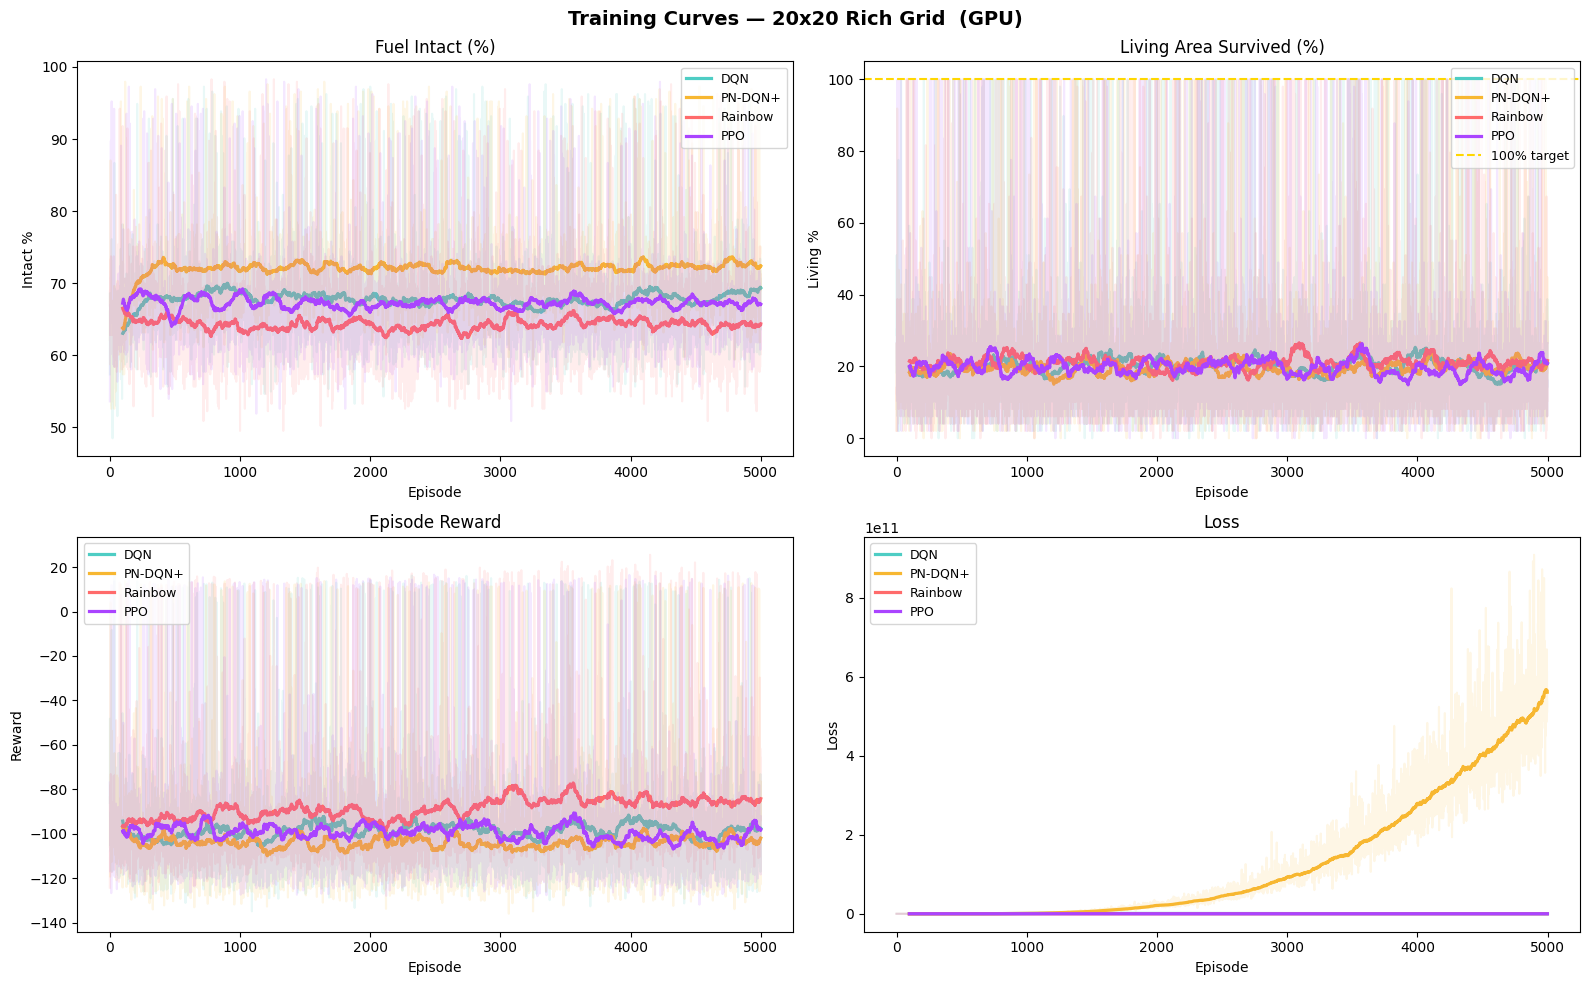

Saved → training_curves.png


In [14]:
W  = 100
CD = '#4ECDC4'; CN = '#F7B731'; CR = '#FF6B6B'; CP = '#AA44FF'

def smooth(x, w=W):
    return np.convolve(x, np.ones(w)/w, mode='valid') if len(x)>=w else np.array(x)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def plot_m(ax, d, n, r, pp, title, ylabel):
    for vals, col, lbl in [(d,CD,'DQN'),(n,CN,'PN-DQN+'),(r,CR,'Rainbow'),(pp,CP,'PPO')]:
        ax.plot(vals, alpha=0.12, color=col)
        if len(vals) >= W:
            ax.plot(range(W-1,len(vals)), smooth(vals,W), color=col, lw=2.3, label=lbl)
    ax.set_title(title); ax.set_xlabel('Episode'); ax.set_ylabel(ylabel); ax.legend(fontsize=9)

plot_m(axes[0,0], dqn_pct,  pn_pct,  rb_pct,  ppo_pct,  'Fuel Intact (%)',          'Intact %')
plot_m(axes[0,1], dqn_bpct, pn_bpct, rb_bpct, ppo_bpct, 'Living Area Survived (%)', 'Living %')
plot_m(axes[1,0], dqn_r,    pn_r,    rb_r,    ppo_r,    'Episode Reward',            'Reward')
plot_m(axes[1,1], dqn_l,    pn_l,    rb_l,    ppo_l,    'Loss',                      'Loss')
axes[0,1].axhline(100, color='gold', lw=1.5, ls='--', label='100% target')
axes[0,1].legend(fontsize=9)

plt.suptitle('Training Curves — 20x20 Rich Grid  (GPU)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved → training_curves.png")

In [15]:
N_EVAL = PARAMS['n_eval']

def evaluate(env, policy_fn, n=N_EVAL):
    intact_l=[]; living_l=[]; eff_l=[]
    for seed in range(n):
        np.random.seed(seed+900); random.seed(seed+900)
        state = env.reset()
        total_cuts=0; adj_cuts=0; step=0
        while True:
            acts = policy_fn(state, step)
            for a in acts:
                r2,c2 = divmod(a, env.G)
                if env.fuel[r2,c2] > 0: total_cuts+=1
                if any(0<=r2+dr<env.G and 0<=c2+dc<env.G and
                       env.fire_state[r2+dr,c2+dc]==env.BURNING
                       for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]): adj_cuts+=1
            state,_,done,info = env.step(acts); step+=1
            if done: break
        intact_l.append(info['intact']/max(env.initial_burnable,1)*100)
        living_l.append(info['living_intact']/max(info['living_total'],1)*100)
        eff_l.append(adj_cuts/max(total_cuts,1)*100)
    return {'intact':intact_l,'living':living_l,'eff':eff_l}


no_agent_fn = lambda s,t: [0]*PARAMS['n_cuts_per_step']
dqn_fn      = lambda s,t: dqn_agent.act(s, greedy=True)
pn_fn       = lambda s,t: pn_agent.act(s, greedy=True, use_eval=True)
rb_fn       = lambda s,t: rb_agent.act(s, greedy=True)
ppo_fn      = lambda s,t: ppo_agent.act(s, greedy=True)[0]

eval_env = RichFireEnv(PARAMS, OBS_CH)
res_b = evaluate(eval_env, no_agent_fn)
res_d = evaluate(eval_env, dqn_fn)
res_n = evaluate(eval_env, pn_fn)
res_r = evaluate(eval_env, rb_fn)
res_p = evaluate(eval_env, ppo_fn)

results = {'No Agent':res_b,'DQN':res_d,'PN-DQN+':res_n,'Rainbow':res_r,'PPO':res_p}

print('='*74)
print(f'{"Model":<12} {"Fuel%":>8} {"Living%":>9} {"FuelImp":>9} {"LivImp":>9} {"FbkEff%":>9}')
print('-'*74)
b0 = np.mean(res_b['intact']); b0l = np.mean(res_b['living'])
for name, res in results.items():
    fi = np.mean(res['intact']); fl = np.mean(res['living'])
    ei = fi-b0; el = fl-b0l; eff = np.mean(res['eff'])
    ok = ' <<' if name!='No Agent' and el>0 else ''
    print(f'{name:<12} {fi:>8.2f} {fl:>9.2f} {ei:>+9.2f} {el:>+9.2f} {eff:>9.1f}{ok}')
print('='*74)
print()
print('Living area improvement over No Agent (percentage points):')
for name, res in results.items():
    if name != 'No Agent':
        imp = np.mean(res['living']) - b0l
        print(f'  {name:<12}: {imp:+.1f} pp  (living survival: {np.mean(res["living"]):.1f}%)')

Model           Fuel%   Living%   FuelImp    LivImp   FbkEff%
--------------------------------------------------------------------------
No Agent        73.69     19.86     +0.00     +0.00       0.0
DQN             68.81     23.91     -4.88     +4.05      11.9 <<
PN-DQN+         72.86     19.97     -0.84     +0.10       5.9 <<
Rainbow         64.50     22.45     -9.19     +2.59       8.4 <<
PPO             71.30     22.59     -2.39     +2.72      13.7 <<

Living area improvement over No Agent (percentage points):
  DQN         : +4.0 pp  (living survival: 23.9%)
  PN-DQN+     : +0.1 pp  (living survival: 20.0%)
  Rainbow     : +2.6 pp  (living survival: 22.4%)
  PPO         : +2.7 pp  (living survival: 22.6%)


Saved → fire_comparison_20x20.gif


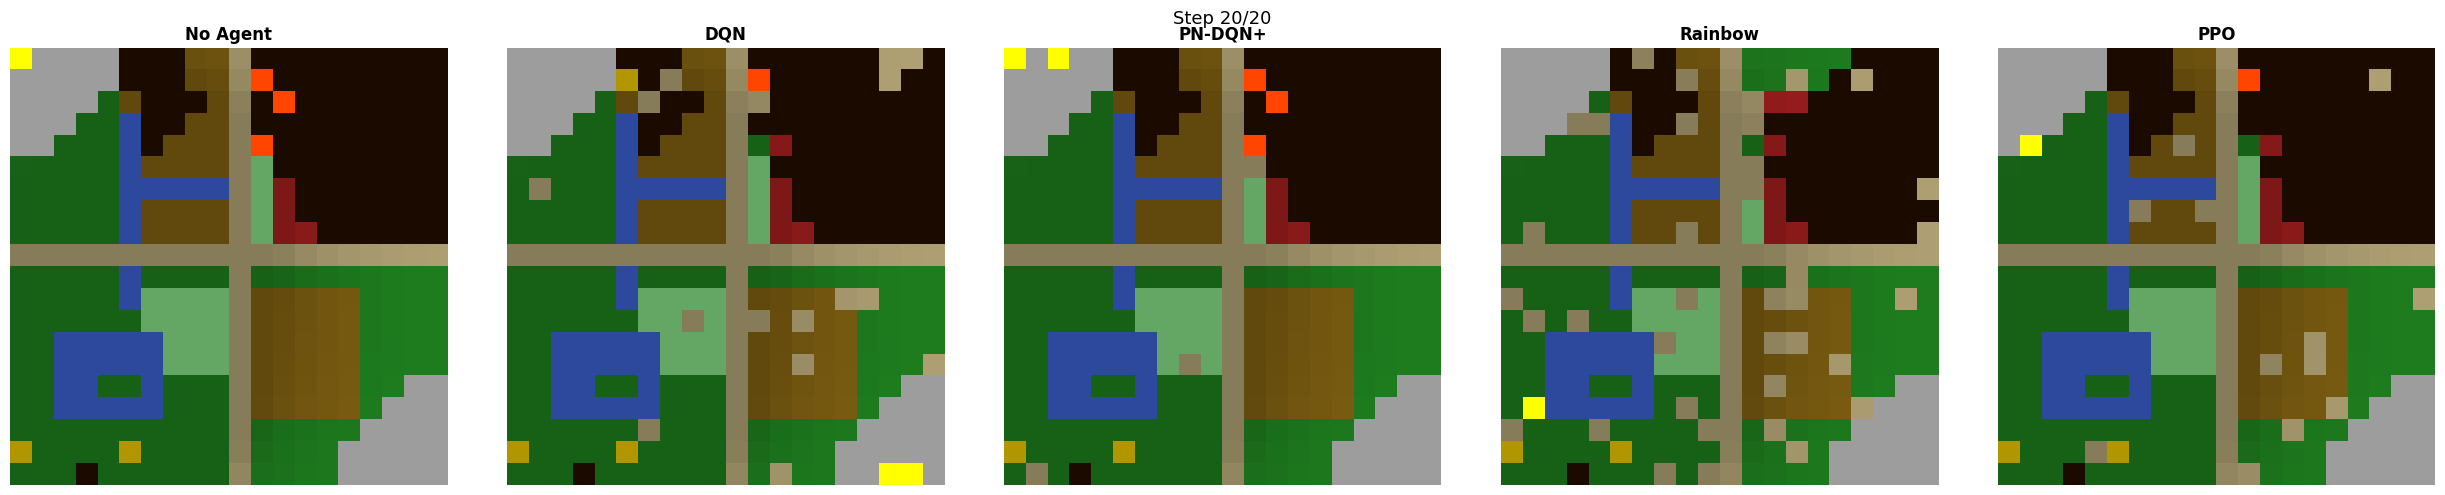

In [16]:
ASEED = PARAMS['anim_seed']
NCUTS = PARAMS['n_cuts_per_step']

def collect_frames(env, policy_fn, seed=ASEED):
    np.random.seed(seed); random.seed(seed)
    state = env.reset(); frames=[env.render_rgb()]; cuts=[[]]; step=0
    while True:
        acts = policy_fn(state, step)
        cut_cells = [divmod(a, env.G) for a in acts if env.fuel[divmod(a,env.G)[0],divmod(a,env.G)[1]] > 0]
        state,_,done,info = env.step(acts)
        frames.append(env.render_rgb()); cuts.append(cut_cells); step+=1
        if done: break
    return frames, cuts

e_b   = RichFireEnv(PARAMS, OBS_CH); e_d   = RichFireEnv(PARAMS, OBS_CH)
e_pn  = RichFireEnv(PARAMS, OBS_CH); e_rb  = RichFireEnv(PARAMS, OBS_CH)
e_ppo = RichFireEnv(PARAMS, OBS_CH)

frm_b,   cut_b   = collect_frames(e_b,   lambda s,t:[0]*NCUTS)
frm_d,   cut_d   = collect_frames(e_d,   lambda s,t: dqn_agent.act(s, greedy=True))
frm_pn,  cut_pn  = collect_frames(e_pn,  lambda s,t: pn_agent.act(s, greedy=True, use_eval=True))
frm_rb,  cut_rb  = collect_frames(e_rb,  lambda s,t: rb_agent.act(s, greedy=True))
frm_ppo, cut_ppo = collect_frames(e_ppo, lambda s,t: ppo_agent.act(s, greedy=True)[0])

T = min(len(frm_b), len(frm_d), len(frm_pn), len(frm_rb), len(frm_ppo))
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
ims = [ax.imshow(np.ones((G,G,3)), origin='upper') for ax in axes]
titles = ['No Agent', 'DQN', 'PN-DQN+', 'Rainbow', 'PPO']
for ax, ttl in zip(axes, titles):
    ax.set_title(ttl, fontsize=12, fontweight='bold')
    ax.axis('off')

def animate(t):
    for im, frm, cuts in zip(ims,
                              [frm_b,frm_d,frm_pn,frm_rb,frm_ppo],
                              [cut_b,cut_d,cut_pn,cut_rb,cut_ppo]):
        rgb = frm[t].copy()
        for r,c in cuts[t]:
            if 0<=r<G and 0<=c<G: rgb[r,c] = [1.0, 1.0, 0.0]
        im.set_data(rgb)
    fig.suptitle(f'Step {t}/{T-1}', fontsize=13)
    return ims

ani = animation.FuncAnimation(fig, animate, frames=T, interval=250, blit=True)
plt.tight_layout()
try:
    html = HTML(ani.to_jshtml())
    display(html)
except Exception as ex:
    print(f'HTML display skipped: {ex}')
try:
    ani.save('fire_comparison_20x20.gif', writer='pillow', fps=4, dpi=80)
    print('Saved → fire_comparison_20x20.gif')
except Exception as ex:
    print(f'GIF save skipped: {ex}')